# DApps開発

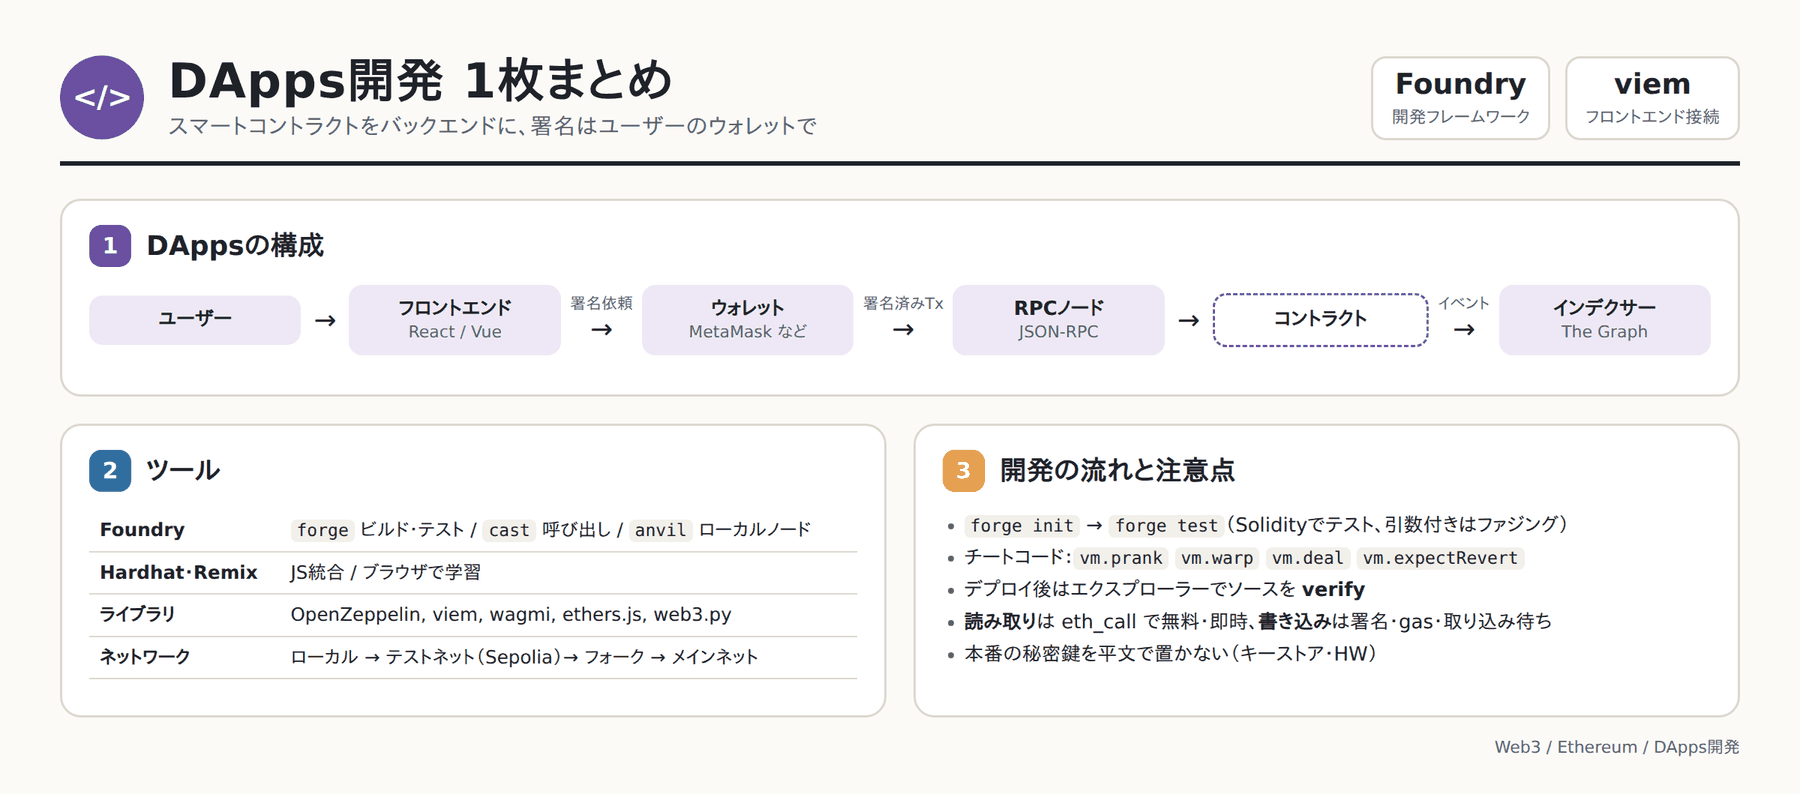

## DAppsの構成

**DApps（Decentralized Applications）** は、スマートコントラクトをバックエンドとするアプリケーション。典型的な構成は次のとおり。

```mermaid
flowchart LR
    User["ユーザー"] --> FE["フロントエンド<br/>（React, Vue など）"]
    FE -->|"署名を依頼"| Wallet["ウォレット<br/>（MetaMask など）"]
    Wallet -->|"署名済みTx"| RPC["RPCノード<br/>（Infura, Alchemy, 自前ノード）"]
    FE -->|"読み取り（eth_call）"| RPC
    RPC --> Chain["ブロックチェーン<br/>（スマートコントラクト）"]
    Chain -->|"イベント"| Indexer["インデクサー<br/>（The Graph など）"]
    Indexer --> FE
```

| 構成要素 | 役割 |
| --- | --- |
| スマートコントラクト | 資産とビジネスロジックを管理するバックエンド |
| フロントエンド | 普通のWebアプリ。コントラクトの読み取りとトランザクションの作成を行う |
| ウォレット | 秘密鍵を管理し、ユーザーの確認を経てトランザクションに署名する |
| RPCノード | JSON-RPC（`eth_call`, `eth_sendRawTransaction` など）でブロックチェーンとやりとりする窓口 |
| インデクサー | イベントを収集・整理してクエリしやすくする。コントラクトから直接「全保有者の一覧」などを取るのは難しいため |

秘密鍵をサーバーに置かず、署名はユーザーのウォレットで行うのが基本。

## 開発ツール

### コントラクト開発フレームワーク

| ツール | 言語 | 特徴 |
| --- | --- | --- |
| Foundry | Solidity（テストもSolidityで書く）, Rust製 | 高速。ファジングやフォークテストが充実。現在の主流 |
| Hardhat | JavaScript / TypeScript | プラグインが豊富。フロントエンドとの統合がしやすい |
| Remix | ブラウザ | インストール不要。学習やちょっとした検証向け |

Foundryは次のツールからなる。

| コマンド | 役割 |
| --- | --- |
| `forge` | ビルド、テスト、デプロイ |
| `cast` | コマンドラインからコントラクトの呼び出しやトランザクションの送信、データのエンコード・デコード |
| `anvil` | ローカルで動くEthereumノード（テスト用の資金を持つアカウントがあらかじめ用意される） |
| `chisel` | SolidityのREPL |

### ライブラリ

| 種類 | 例 |
| --- | --- |
| コントラクトのライブラリ | OpenZeppelin Contracts（ERC-20/721の実装、アクセス制御、プロキシなど）, Solady |
| フロントエンドからのチェーン接続 | viem, ethers.js, web3.js |
| Reactでのウォレット接続 | wagmi, RainbowKit, ConnectKit |
| Pythonからの接続 | web3.py |

### ネットワーク

| ネットワーク | 用途 |
| --- | --- |
| ローカル（anvil, Hardhat Network） | 開発・テスト。即座にブロックが作られる |
| テストネット（Sepolia, Hoodi） | 本番に近い環境での検証。テスト用のETHは無料の配布サービス（faucet）で入手する |
| メインネットのフォーク | 本番のステートをローカルに複製して、既存のコントラクトとの連携をテストする |
| メインネット | 本番 |

## Foundryでの開発の流れ

### プロジェクトの作成とテスト

```bash
# インストール
curl -L https://foundry.paradigm.xyz | bash
foundryup

# プロジェクト作成
forge init counter
cd counter
forge build
forge test
```

作成されるディレクトリ構成：

```
counter/
├── foundry.toml      # 設定ファイル
├── src/Counter.sol   # コントラクト
├── test/Counter.t.sol  # テスト
├── script/Counter.s.sol  # デプロイスクリプト
└── lib/              # 依存ライブラリ（forge-std など）
```

テストもSolidityで書く。`test` で始まる関数がテストケースになり、引数を取るテスト関数はファジングテストとして多数のランダムな入力で実行される。

```solidity
// test/Counter.t.sol
import {Test} from "forge-std/Test.sol";
import {Counter} from "../src/Counter.sol";

contract CounterTest is Test {
    Counter counter;

    function setUp() public {
        counter = new Counter();
    }

    function test_Increment() public {
        counter.increment();
        assertEq(counter.number(), 1);
    }

    // ファジング：ランダムなxで何度も実行される
    function testFuzz_SetNumber(uint256 x) public {
        counter.setNumber(x);
        assertEq(counter.number(), x);
    }
}
```

`vm.prank`（次の呼び出しの `msg.sender` の偽装）、`vm.warp`（時刻の変更）、`vm.deal`（残高の設定）、`vm.expectRevert`（次の呼び出しが失敗することの検証）などの **チートコード** で、テスト用にチェーンの状態を自由に操作できる。権限チェックのテストなら、`vm.prank` で権限のないアドレスになりすまして `vm.expectRevert` を確認する、といった使い方をする。

### デプロイ

```bash
# ローカルノードを起動
anvil

# 別のターミナルでデプロイ（anvilが表示するテスト用の秘密鍵を使う）
forge script script/Counter.s.sol --rpc-url http://127.0.0.1:8545 --broadcast --private-key <秘密鍵>

# デプロイしたコントラクトを呼び出す
cast call <コントラクトアドレス> "number()(uint256)" --rpc-url http://127.0.0.1:8545
cast send <コントラクトアドレス> "increment()" --rpc-url http://127.0.0.1:8545 --private-key <秘密鍵>
```

テストネットやメインネットにデプロイしたら、Etherscanなどのエクスプローラーでソースコードを **verify** しておく。ソースコードが公開・照合されていると、ユーザーがコントラクトの中身を確認でき、エクスプローラー上から関数を呼び出すこともできる。

:::{warning}
本番用の秘密鍵をコマンドライン引数や `.env` ファイルに平文で置かないこと。`cast wallet import` で暗号化したキーストアを使うか、ハードウェアウォレットで署名する。
:::

## フロントエンドからの呼び出し

viemを使ってコントラクトを読み書きする例（TypeScript）：

```typescript
import { createPublicClient, createWalletClient, custom, http, parseAbi } from "viem";
import { sepolia } from "viem/chains";

const abi = parseAbi([
  "function number() view returns (uint256)",
  "function increment()",
]);
const address = "0x...";

// 読み取り：署名不要・gas不要（RPCノードで eth_call を実行するだけ）
const publicClient = createPublicClient({ chain: sepolia, transport: http() });
const n = await publicClient.readContract({ address, abi, functionName: "number" });

// 書き込み：ブラウザのウォレット（MetaMaskなど）で署名してトランザクションを送る
const walletClient = createWalletClient({ chain: sepolia, transport: custom(window.ethereum) });
const [account] = await walletClient.requestAddresses();
const hash = await walletClient.writeContract({ address, abi, functionName: "increment", account });
await publicClient.waitForTransactionReceipt({ hash });
```

ポイント：

- **読み取り**（`view` 関数）はトランザクションではなく、RPCノード上でのシミュレーション実行なので無料で即座に結果が返る
- **書き込み**はトランザクションを送るので、ウォレットでの署名、gas代、ブロックへの取り込み待ちが必要。UIでは「送信中」「確定」などの状態を表示する
- コントラクトのイベントを購読して、状態の変化をUIに反映する

## 参考文献

- [Foundry Book](https://www.getfoundry.sh/)
- [viem](https://viem.sh/) / [wagmi](https://wagmi.sh/)
- [OpenZeppelin Contracts](https://docs.openzeppelin.com/contracts/)
- [Ethereum JSON-RPC API](https://ethereum.org/developers/docs/apis/json-rpc/)